In [20]:
import torch

# ตรวจสอบและใช้งาน GPU ของชิป M4
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"รันโมเดลบน: {device}")

รันโมเดลบน: mps


In [21]:
import numpy as np
from scipy.io import loadmat

path = '../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR0dB_O1_140_Ant64/'
d1 = loadmat(path+'channel1.mat')['a']
d2 = loadmat(path+'channel2.mat')['b']
d3 = loadmat(path+'channel3.mat')['c']

data = np.concatenate((d1, d2, d3), axis=2).transpose(2, 0, 1)

d_r = data.real.reshape(-1, 1, 64, 32)
d_i = data.imag.reshape(-1, 1, 64, 32)

X = np.concatenate((d_r, d_i), axis=1)
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / (std + 1e-8) # 1e-8 prevents division by zero

print("Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.")

# Load Label (One-hot encoding)
y = loadmat(path+'DLCB_output.mat')['onehot_label']

print(f"Input shape: {X.shape}")
print(f"Label shape: {y.shape}")

Data normalization complete. Features now have Mean ≈ 0 and Std ≈ 1.
Input shape: (53467, 2, 64, 32)
Label shape: (53467, 64)


In [22]:
from torch.utils.data import DataLoader, TensorDataset

split_idx = int(len(X) * 0.7)

# Training set: The first 70% of the user path
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Data Split Complete:")
print(f" - Training samples: {len(X_train)} (First 70%)")
print(f" - Testing samples:  {len(X_test)} (Last 30% - Future Path)")

train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
test_ds = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

Data Split Complete:
 - Training samples: 37426 (First 70%)
 - Testing samples:  16041 (Last 30% - Future Path)


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BeamPredictionCNN(nn.Module):
    def __init__(self, n_beams):
        super(BeamPredictionCNN, self).__init__()
        
        # ส่วนสกัดฟีเจอร์ (Conv Layers)
        self.cnn = nn.Sequential(
            # Conv Layer 1: รับ 2 channels, ส่งออก 16 channels, kernel 3x3
            nn.Conv2d(in_channels=2, out_channels=16, kernel_size=3, padding=1, bias=False),
            nn.Dropout(0.1),
            
            # Conv Layer 2: รับ 16 channels, ส่งออก 48 channels
            nn.Conv2d(in_channels=16, out_channels=48, kernel_size=3, padding=1, bias=False),
            
            # Max Pooling 4x4 เพื่อลดขนาด
            # จาก (64, 32) จะเหลือ (16, 8)
            nn.MaxPool2d(kernel_size=4),
            nn.Dropout(0.1)
        )
        
        # ส่วนตัดสินใจ (Fully Connected Layers)
        # คำนวณ Input size: 48 channels * 16 * 8 = 6144
        self.linear = nn.Sequential(
            nn.Linear(6144, 511),
            nn.ReLU(),
            nn.Linear(511, n_beams) # ปรับให้ตรงกับจำนวนบีม (64)
        )

    def forward(self, x):
        # สกัดฟีเจอร์ด้วย CNN
        x = self.cnn(x)
        
        # Flatten ข้อมูลเพื่อเข้า Linear layer
        x = x.view(x.size(0), -1) 
        
        # ทำนายผล
        x = self.linear(x)
        return x

In [24]:
model = BeamPredictionCNN(n_beams=64).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Params: {params}')

Total Trainable Params: 3180063


In [25]:
epochs = 100
for epoch in range(epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        # Use torch.max to find the best index of beam for CrossEntropyLoss
        loss = criterion(outputs, torch.max(labels, 1)[1])
        loss.backward()
        optimizer.step()
        
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.2508
Epoch [20/100], Loss: 0.3775
Epoch [30/100], Loss: 0.2364
Epoch [40/100], Loss: 0.2279
Epoch [50/100], Loss: 0.4308
Epoch [60/100], Loss: 0.1544
Epoch [70/100], Loss: 0.1834
Epoch [80/100], Loss: 0.0837
Epoch [90/100], Loss: 0.1120
Epoch [100/100], Loss: 0.1143


In [26]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        _, actual = torch.max(labels.data, 1)
        total += labels.size(0)
        correct += (predicted == actual).sum().item()
        
print(f'Average Accuracy on SNR 0dB: {100 * correct / total:.2f}%')

Average Accuracy on SNR 0dB: 92.32%


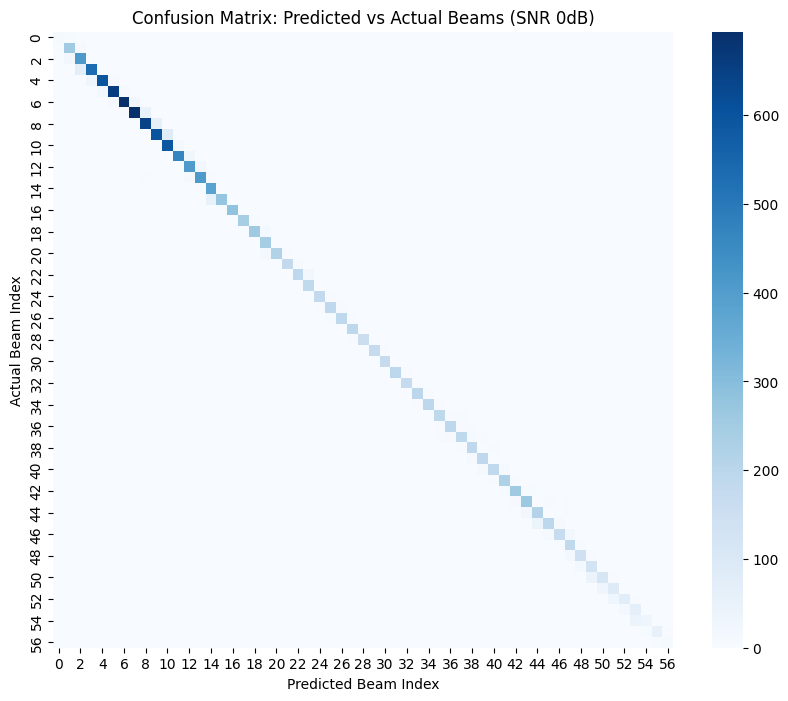

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# เก็บค่าผลลัพธ์ทั้งหมด
all_preds = []
all_actuals = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        _, actual = torch.max(labels, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_actuals.extend(actual.cpu().numpy())

# สร้าง Confusion Matrix
cm = confusion_matrix(all_actuals, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Beams (SNR 0dB)')
plt.xlabel('Predicted Beam Index')
plt.ylabel('Actual Beam Index')
plt.show()

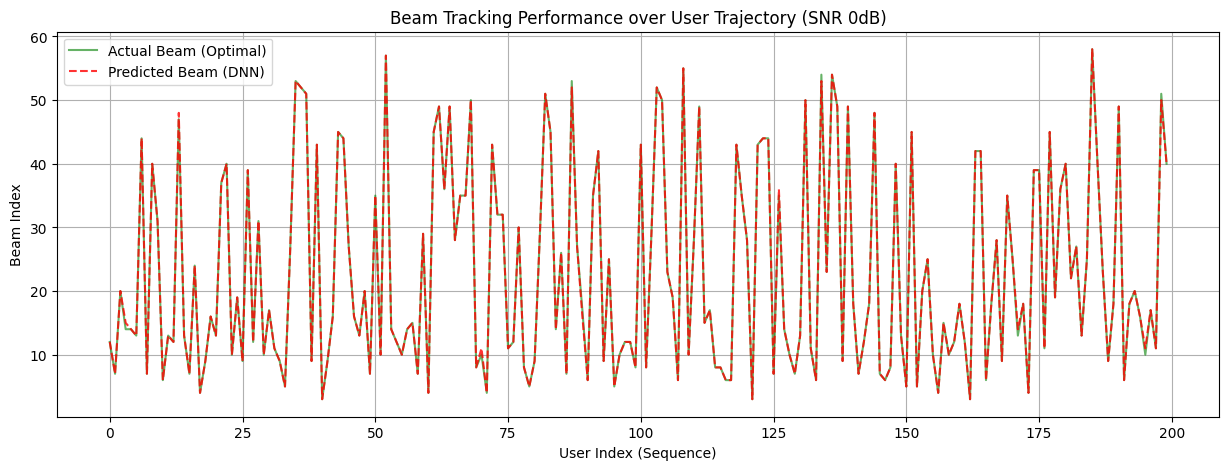

In [28]:
plt.figure(figsize=(15, 5))
plt.plot(all_actuals[:200], 'g-', label='Actual Beam (Optimal)', alpha=0.6)
plt.plot(all_preds[:200], 'r--', label='Predicted Beam (DNN)', alpha=0.8)
plt.title('Beam Tracking Performance over User Trajectory (SNR 0dB)')
plt.xlabel('User Index (Sequence)')
plt.ylabel('Beam Index')
plt.legend()
plt.grid(True)
plt.show()